# PRESELECCIÓN DE VARIABLES

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

Cargar los datos.

In [2]:
df = pd.read_pickle("../02_datos/03_Entrenamiento/df_tablon_transformado.pkl")

## MÉTODOS SUPERVISADOS

### Preparar x e y

In [3]:
target = 'ventas'
x = df.drop(columns = ['date','store_id','item_id','ventas']).copy()
y =  df[target].copy()

### Mutual Information

#### Crear una función para mostrar el resultado

In [4]:
def ranking_mi(mutual_selector, modo = 'tabla'):
    #Maqueta el ranking
    ranking_mi = pd.DataFrame(mutual_selector, index = x.columns).reset_index()
    ranking_mi.columns = ['variable','importancia_mi']
    ranking_mi = ranking_mi.sort_values(by = 'importancia_mi', ascending = False)
    ranking_mi['ranking_mi'] = np.arange(0,ranking_mi.shape[0])
    #Muestra la salida
    if modo == 'tabla':
        return(ranking_mi)
    else:
        g = ranking_mi.importancia_mi.sort_values().plot.barh(figsize = (12,20))
        g.set_yticklabels(ranking_mi.sort_values(by = 'importancia_mi').variable)
        return(g)

#### Calcular y revisar

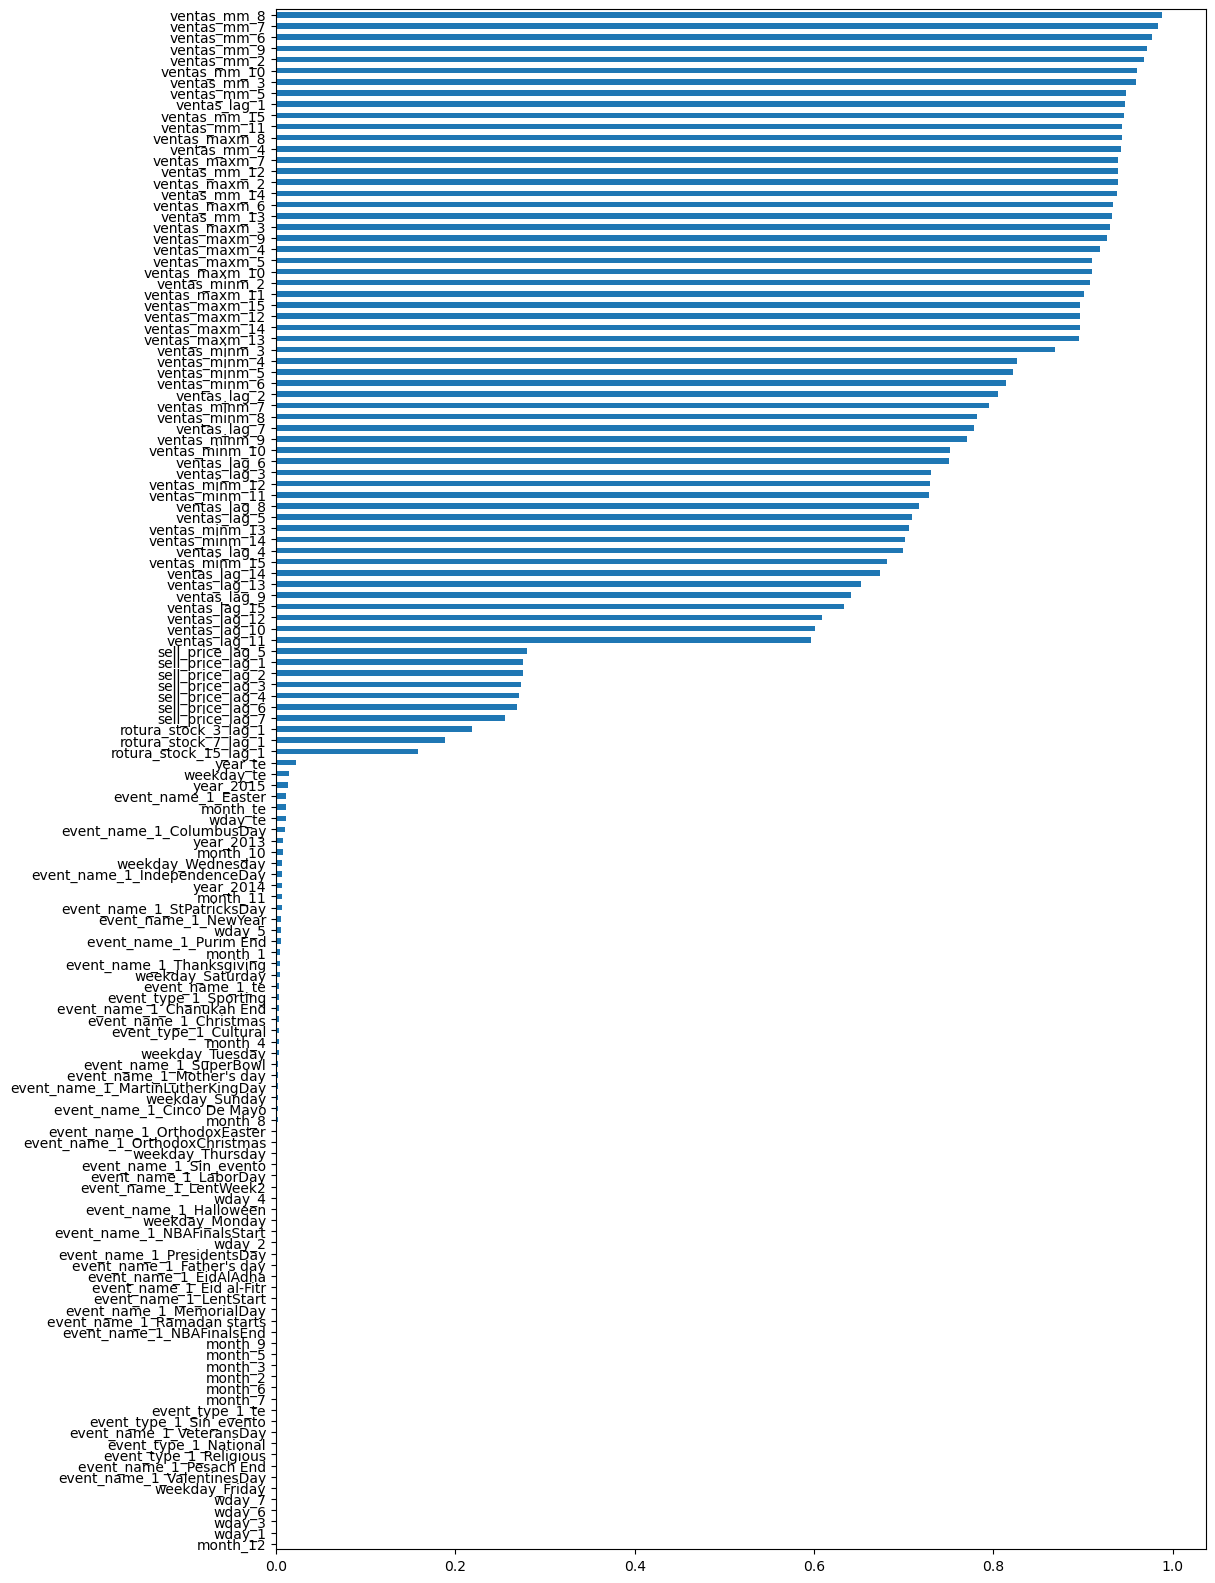

In [5]:
mutual_selector = mutual_info_regression(x,y)

rank_mi = ranking_mi(mutual_selector, modo = 'grafico')

#### Seleccionar las variables que pasan

##### Definir la posición de la última variable que va a entrar

Miramos la posición de la última variable que queremos.

In [6]:
ranking_mi(mutual_selector).reset_index().iloc[60:100]

,index,variable,importancia_mi,ranking_mi
60,73,sell_price_lag_3,0.273,60
61,74,sell_price_lag_4,0.270,61
62,76,sell_price_lag_6,0.268,62
63,77,sell_price_lag_7,0.255,63
64,78,rotura_stock_3_lag_1,0.219,64
65,79,rotura_stock_7_lag_1,0.189,65
66,80,rotura_stock_15_lag_1,0.158,66
67,65,year_te,0.022,67
68,68,weekday_te,0.015,68
69,2,year_2015,0.013,69


In [7]:
posicion_variable_limite = 75

##### Extraer los nombres de las que entran

In [8]:
entran_mi = ranking_mi(mutual_selector).iloc[0:posicion_variable_limite].variable

##### Crear el dataframe con la selección

In [9]:
x_mi = x[entran_mi].copy()

### Recursive Feature Elimination

#### Instanciar

In [10]:
rfe = RFE(estimator = XGBRegressor(n_jobs = -1, eval_metric='mae'))

#### Entrenar

In [11]:
rfe.fit(x,y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).","XGBRegressor(...ree=None, ...)"
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",None
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None


##### Extraer los nombres de las que entran

In [12]:
entran_rfe = x.columns[rfe.support_]

#### Crear el dataframe con la selección

In [13]:
x_rfe = x[entran_rfe].copy()

In [14]:
x_rfe

,year_2013,month_3,month_11,month_12,wday_1,wday_2,event_name_1_Christmas,event_name_1_Thanksgiving,event_name_1_VeteransDay,wday_te,...,ventas_maxm_4,ventas_maxm_5,ventas_maxm_6,ventas_maxm_7,ventas_maxm_8,ventas_maxm_9,ventas_maxm_10,ventas_maxm_11,ventas_maxm_13,ventas_maxm_15
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,24.894,...,351.000,351.000,351.000,351.000,351.000,351.000,351.000,351.000,351.000,351.000
1,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,26.096,...,281.000,351.000,351.000,351.000,351.000,351.000,351.000,351.000,351.000,351.000
2,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,29.476,...,206.000,281.000,351.000,351.000,351.000,351.000,351.000,351.000,351.000,351.000
3,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,34.801,...,224.000,224.000,281.000,351.000,351.000,351.000,351.000,351.000,351.000,351.000
4,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,34.385,...,362.000,362.000,362.000,362.000,362.000,362.000,362.000,362.000,362.000,362.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20975,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,26.096,...,15.000,15.000,15.000,15.000,15.000,15.000,15.000,17.000,17.000,17.000
20976,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,29.476,...,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22.000
20977,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,34.801,...,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22.000
20978,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,34.385,...,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22.000


### Permutation Importance

#### Crear una función para mostrar el resultado

In [15]:
def ranking_per(predictoras,permutacion):
    ranking_per = pd.DataFrame({'variable': predictoras.columns, 'importancia_per': permutacion.importances_mean}).sort_values(by = 'importancia_per', ascending = False)
    ranking_per['ranking_per'] = np.arange(0,ranking_per.shape[0])
    return(ranking_per)

#### Instanciar y entrenar

In [16]:
xgb = XGBRegressor(n_jobs = -1, eval_metric='mae')

xgb.fit(x,y)

permutacion = permutation_importance(xgb, 
                                     x, y, 
                                     scoring = 'neg_mean_absolute_percentage_error',
                                     n_repeats=3, n_jobs = -1)

#### Revisar la salida

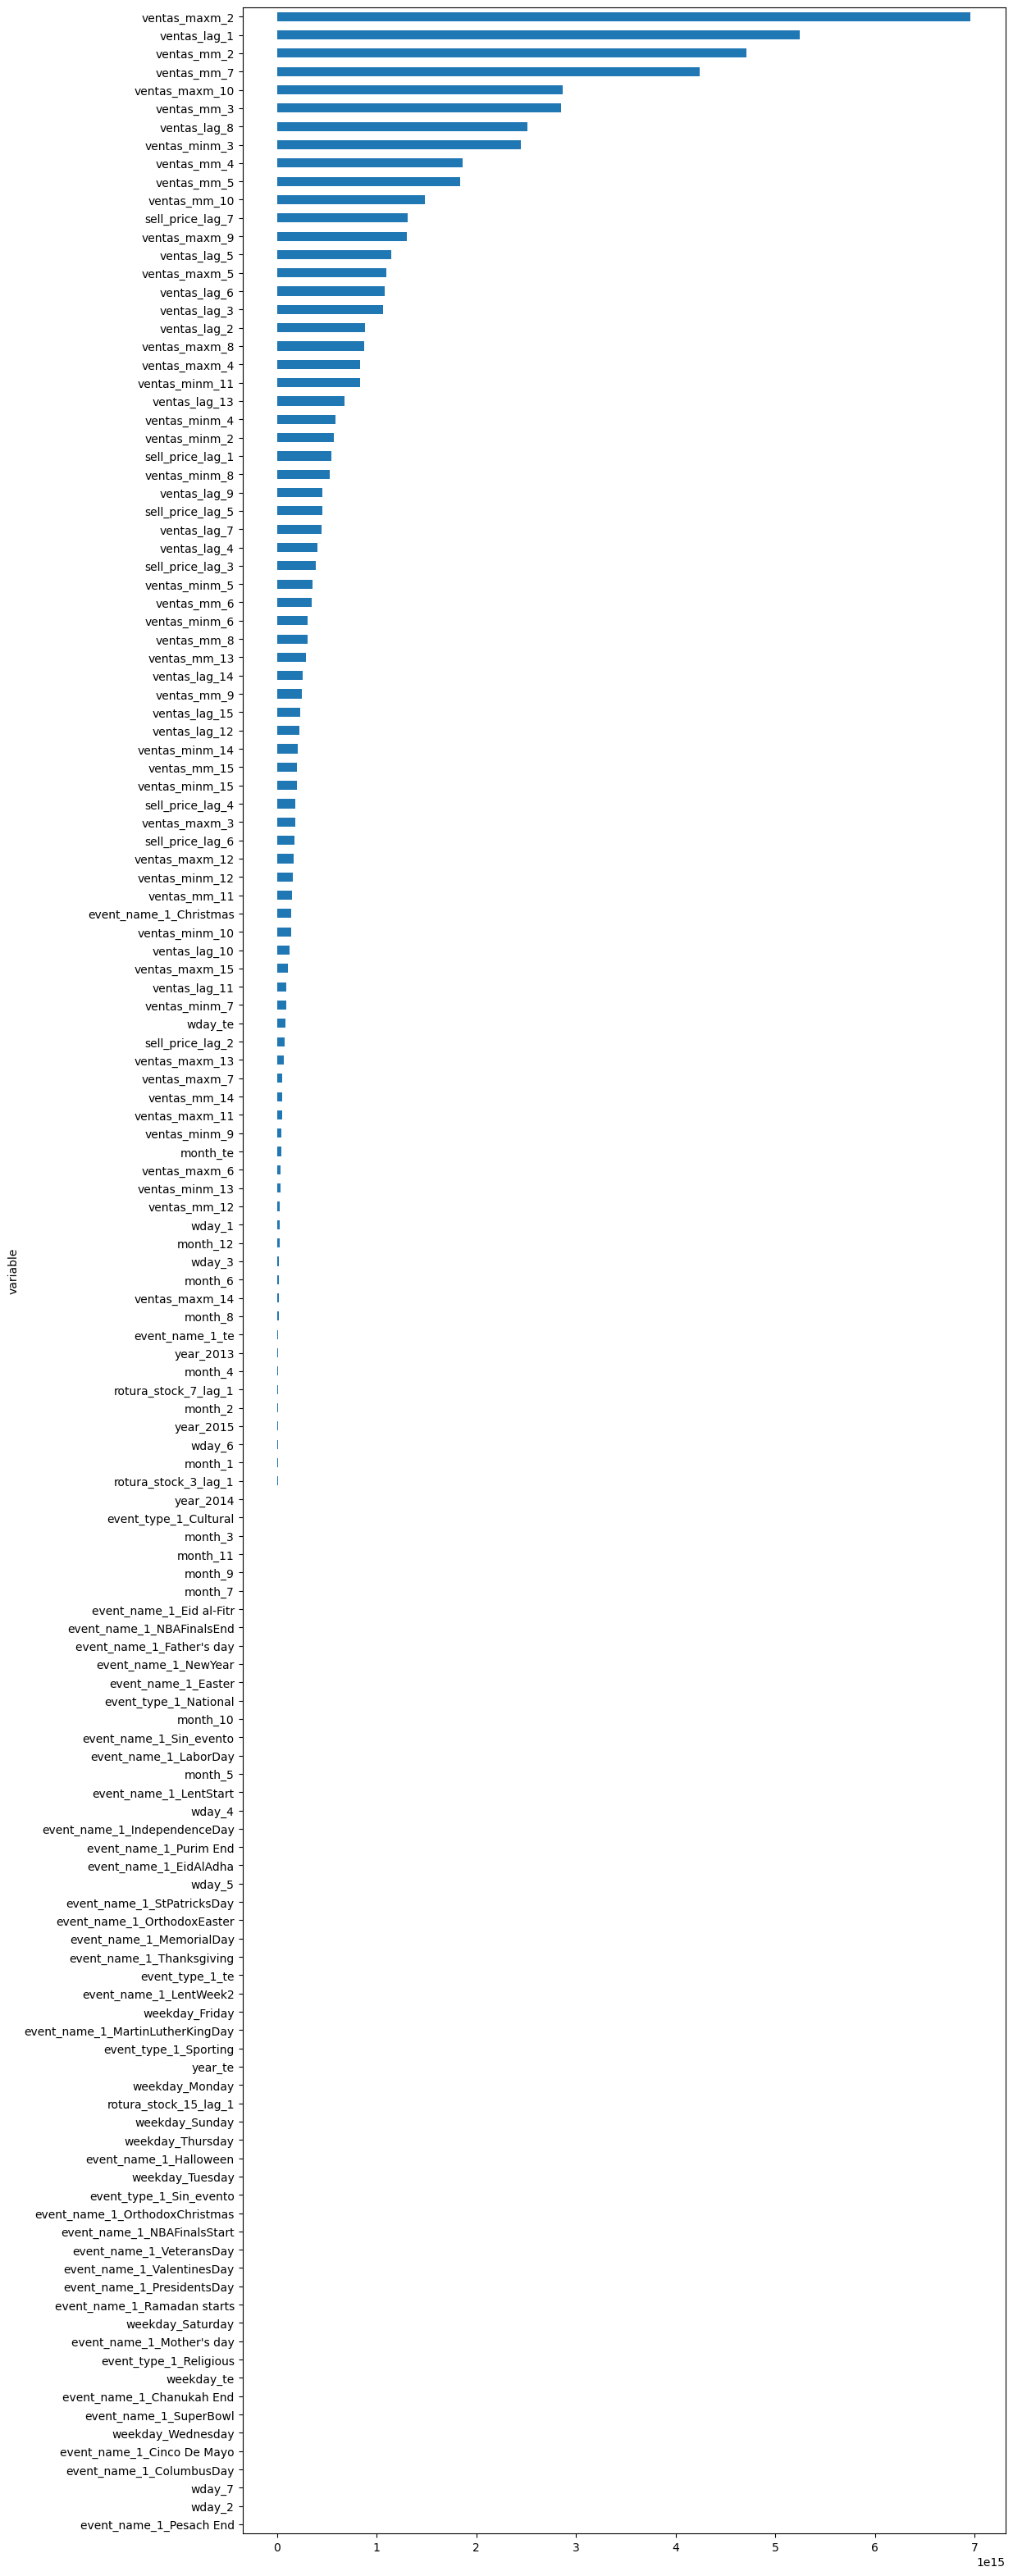

In [17]:
rank_per = ranking_per(x,permutacion)

rank_per.set_index('variable').importancia_per.sort_values().plot.barh(figsize = (12,40));

#### Seleccionar las variables que pasan

##### Definir la posición de la última variable que va a entrar

In [18]:
rank_per.reset_index().iloc[50:100]

,index,variable,importancia_per,ranking_per
50,104,ventas_minm_10,141980344516608.000,50
51,90,ventas_lag_10,125127340239530.672,51
52,137,ventas_maxm_15,112180563978922.672,52
53,91,ventas_lag_11,94688101706410.672,53
54,101,ventas_minm_7,89209915659605.328,54
55,67,wday_te,87030175017642.672,55
56,72,sell_price_lag_2,77107458386602.672,56
57,135,ventas_maxm_13,68543919947776.000,57
58,129,ventas_maxm_7,49615730638848.000,58
59,122,ventas_mm_14,48303125998250.664,59


In [19]:
posicion_variable_limite = 74

##### Extraer los nombres de las que entran

In [20]:
entran_per = rank_per.iloc[0:posicion_variable_limite].variable

##### Crear el dataframe con la selección

In [21]:
x_per = x[entran_per].copy()

## SELECCIONAR EL MÉTODO FINAL

In [22]:
x_preseleccionado = x_mi
#x_preseleccionado = x_rfe
#x_preseleccionado = x_per

## INCORPORACION DE VARIABLES DE SEGMENTACION

Vamos a añadir las variables de segmentación que también necesitaremos.

In [23]:
x_preseleccionado = pd.concat([df[['date','store_id','item_id']], x_preseleccionado], axis=1)

In [24]:
x_preseleccionado.to_pickle("../02_datos/03_Entrenamiento/x_preseleccionado.pkl")
y_preseleccionado = pd.DataFrame({'ventas': y.copy()})
y_preseleccionado.to_pickle("../02_datos/03_Entrenamiento/y_preseleccionado.pkl")